# 🌌 Asteroid Hazard Prediction
**Applied AI Study Group #10 — Week 1 Workshop**

Bu notebook'ta NASA'nın asteroid verilerini kullanarak bir **tehlike tespit modeli** kuracağız.

## Problem
Bir asteroidin Dünya'ya tehlikeli olup olmadığını tahmin edebilir miyiz?

- **Input:** Asteroidin fiziksel ve orbital özellikleri
- **Output:** Tehlikeli mi? (1 = Hazardous, 0 = Not Hazardous)
- **ML Problem Type:** Binary Classification

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print('Setup complete')

Setup complete


## 2. Load Data

In [2]:
df = pd.read_csv('../data/asteroids.csv')
print(f'Dataset shape: {df.shape}')
print(f'Hazardous: {df.is_hazardous.sum()} ({df.is_hazardous.mean()*100:.1f}%)')
print(f'Not hazardous: {(~df.is_hazardous.astype(bool)).sum()} ({(1-df.is_hazardous.mean())*100:.1f}%)')
df.head()

Dataset shape: (1000, 8)
Hazardous: 361 (36.1%)
Not hazardous: 639 (63.9%)


,name,est_diameter_km,relative_velocity_km_s,miss_distance_mKm,absolute_magnitude,eccentricity,inclination_deg,is_hazardous
0,Asteroid_0000,0.2346,10.55,9.10,21.7,0.5148,11.81,0
1,Asteroid_0001,1.5051,21.26,8.51,23.0,0.7249,14.20,1
2,Asteroid_0002,0.6584,31.19,71.02,17.5,0.6841,25.64,1
3,Asteroid_0003,0.4565,26.97,8.61,21.2,0.1385,10.20,1
4,Asteroid_0004,0.0848,29.20,9.52,20.7,0.1343,26.09,1


### Feature Descriptions

| Feature | Description | Unit |
|---------|-------------|------|
| `est_diameter_km` | Estimated diameter | km |
| `relative_velocity_km_s` | Speed relative to Earth | km/s |
| `miss_distance_mKm` | Closest approach distance | million km |
| `absolute_magnitude` | Brightness (lower = larger/closer) | — |
| `eccentricity` | Orbital eccentricity (0=circle, 1=parabola) | — |
| `inclination_deg` | Orbital inclination | degrees |

## 3. Exploratory Data Analysis (EDA)

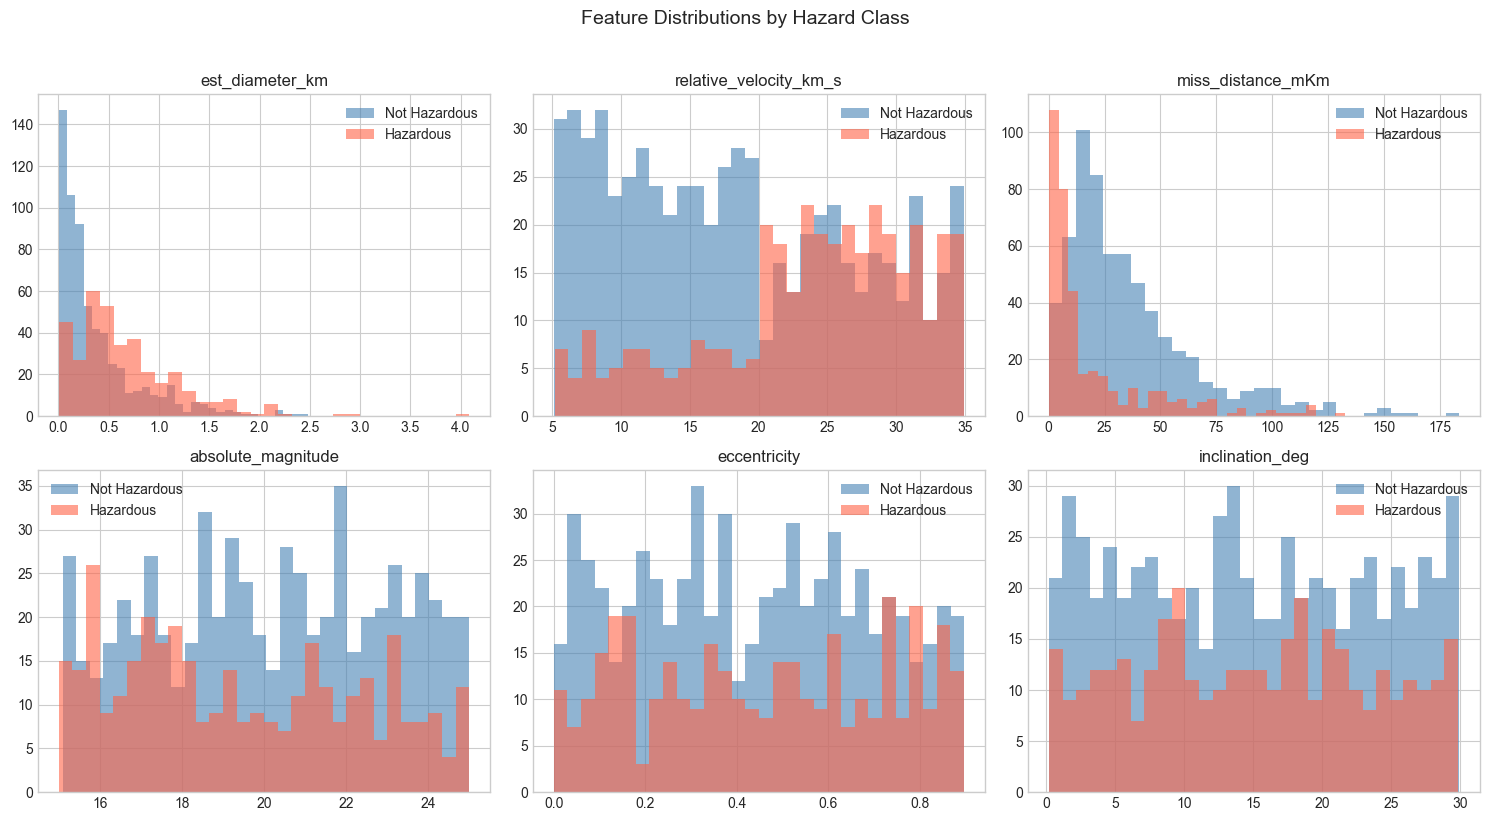

In [3]:
# Distribution of each feature by hazard class
features = ['est_diameter_km', 'relative_velocity_km_s', 'miss_distance_mKm',
            'absolute_magnitude', 'eccentricity', 'inclination_deg']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    df[df.is_hazardous == 0][feat].hist(ax=ax, alpha=0.6, label='Not Hazardous',
                                         color='steelblue', bins=30)
    df[df.is_hazardous == 1][feat].hist(ax=ax, alpha=0.6, label='Hazardous',
                                         color='tomato', bins=30)
    ax.set_title(feat)
    ax.legend()

plt.suptitle('Feature Distributions by Hazard Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

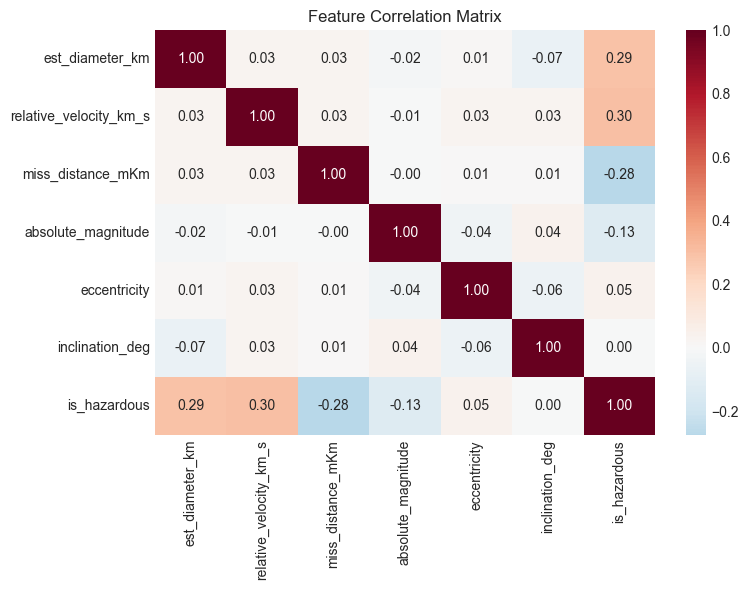


Correlation with is_hazardous:
relative_velocity_km_s    0.302415
est_diameter_km           0.291405
eccentricity              0.048498
inclination_deg           0.003302
absolute_magnitude       -0.126820
miss_distance_mKm        -0.275069
Name: is_hazardous, dtype: float64


In [4]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[features + ['is_hazardous']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print('\nCorrelation with is_hazardous:')
print(corr['is_hazardous'].drop('is_hazardous').sort_values(ascending=False))

## 4. Prepare Data

In [5]:
FEATURES = [
    'est_diameter_km',
    'relative_velocity_km_s',
    'miss_distance_mKm',
    'absolute_magnitude',
    'eccentricity',
    'inclination_deg'
]

X = df[FEATURES]
y = df['is_hazardous']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')
print(f'Train hazardous rate: {y_train.mean():.2%}')
print(f'Test hazardous rate:  {y_test.mean():.2%}')

Train size: 800 | Test size: 200
Train hazardous rate: 36.12%
Test hazardous rate:  36.00%


## 5. Baseline Model — Always Predict "Not Hazardous"

In [6]:
# The dumbest possible model: always predict 0
y_baseline = np.zeros(len(y_test))
baseline_acc = (y_baseline == y_test).mean()

print(f'Baseline Accuracy (always predict Not Hazardous): {baseline_acc:.2%}')
print()
print('Think about this:')
print(f'   {baseline_acc:.2%} accuracy — sounds good?')
print(f'   But we catch 0% of actual hazardous asteroids!')
print()
print('This is the Accuracy Trap from Week 1.')
print('We need Recall — catching real hazardous ones matters most.')

Baseline Accuracy (always predict Not Hazardous): 64.00%

Think about this:
   64.00% accuracy — sounds good?
   But we catch 0% of actual hazardous asteroids!

This is the Accuracy Trap from Week 1.
We need Recall — catching real hazardous ones matters most.


## 6. Logistic Regression — Simple Model

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr,
      target_names=['Not Hazardous', 'Hazardous']))
print(f'ROC-AUC: {roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1]):.4f}')

=== Logistic Regression ===
               precision    recall  f1-score   support

Not Hazardous       0.75      0.91      0.82       128
    Hazardous       0.74      0.47      0.58        72

     accuracy                           0.75       200
    macro avg       0.75      0.69      0.70       200
 weighted avg       0.75      0.75      0.73       200

ROC-AUC: 0.8522


## 7. Random Forest — Better Model

In [8]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf,
      target_names=['Not Hazardous', 'Hazardous']))
print(f'ROC-AUC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]):.4f}')

=== Random Forest ===


               precision    recall  f1-score   support

Not Hazardous       0.90      0.96      0.93       128
    Hazardous       0.92      0.82      0.87        72

     accuracy                           0.91       200
    macro avg       0.91      0.89      0.90       200
 weighted avg       0.91      0.91      0.91       200

ROC-AUC: 0.9660


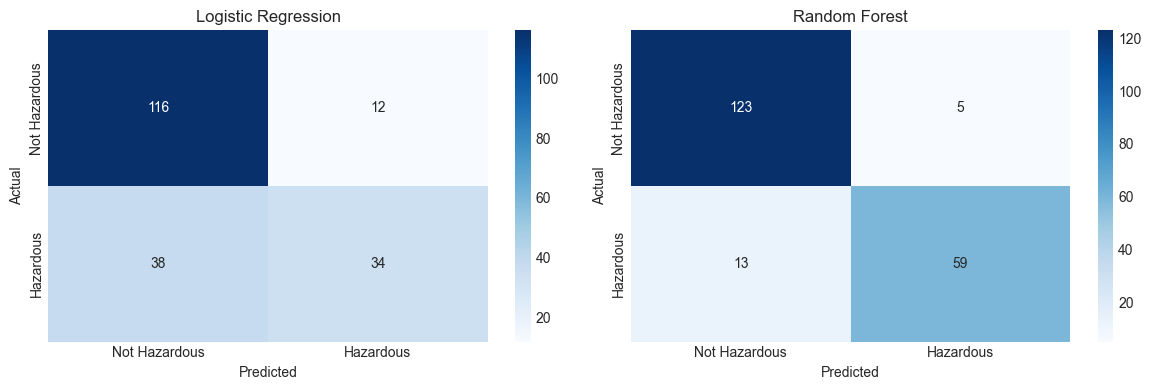

Which model misses fewer actual hazardous asteroids?
False Negatives (bottom-left) = missed hazardous = DANGEROUS


In [9]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, preds) in zip(axes, [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest', y_pred_rf)
]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Hazardous', 'Hazardous'],
                yticklabels=['Not Hazardous', 'Hazardous'])
    ax.set_title(name)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

print('Which model misses fewer actual hazardous asteroids?')
print('False Negatives (bottom-left) = missed hazardous = DANGEROUS')

## 8. Feature Importance

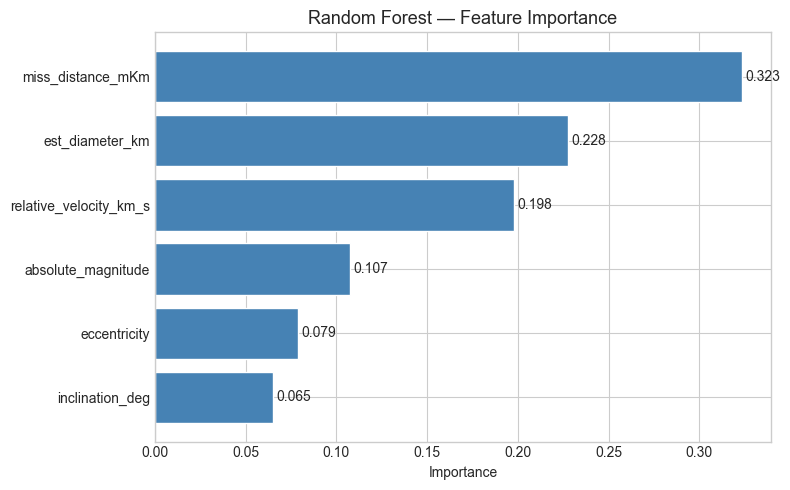

Which features matter most? Does this make physical sense?


In [10]:
importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(importance_df['feature'], importance_df['importance'],
               color='steelblue', edgecolor='white')
ax.set_title('Random Forest — Feature Importance', fontsize=13)
ax.set_xlabel('Importance')

for bar, val in zip(bars, importance_df['importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print('Which features matter most? Does this make physical sense?')

## 9. Save Model

In [11]:
import joblib

joblib.dump(rf, '../models/asteroid_model.pkl')
joblib.dump(FEATURES, '../models/asteroid_features.pkl')

print('Model saved: ../models/asteroid_model.pkl')
print('Features saved: ../models/asteroid_features.pkl')
print()
print('These files will be used in:')
print('  → app.py (Streamlit visualization)')
print('  → Week 2: api.py (FastAPI deployment)')

Model saved: asteroid_model.pkl
Features saved: asteroid_features.pkl

These files will be used in:
  → app.py (Streamlit visualization)
  → Week 2: api.py (FastAPI deployment)


---
## 📝 Ödev

### Zorunlu
1. Notebook'u baştan sona çalıştır
2. `n_estimators` değerini 100'den **50** ve **200**'e değiştir — sonuçlar nasıl değişiyor?
3. `FEATURES` listesinden `inclination_deg`'i çıkar, modeli tekrar eğit — Recall nasıl etkilendi?
4. 3-5 cümle yaz: En önemli feature ne? Neden mantıklı?

### Seçmeli (meraklılar için)
5. Yeni bir feature ekle: `velocity_diameter_ratio = relative_velocity_km_s / est_diameter_km`
   - Bu feature anlamlı mı? Feature importance'ta nerede çıkıyor?
6. Threshold'u değiştir: `rf.predict_proba(X_test)[:, 1] > 0.3` — Recall ne oluyor?

### Lab'a getir
- Farklı `n_estimators` denemelerinin sonuçlarını
- Feature çıkarma/ekleme gözlemlerini
- "Bu modeli gerçek hayatta kullanır mıydın?" sorusuna cevabını

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

experiment_rows = []
for n_estimators in [50, 100, 200]:
    rf_variant = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
    rf_variant.fit(X_train, y_train)
    y_pred_variant = rf_variant.predict(X_test)
    y_proba_variant = rf_variant.predict_proba(X_test)[:, 1]

    experiment_rows.append({
        'model': f'RandomForest ({n_estimators} trees)',
        'accuracy': accuracy_score(y_test, y_pred_variant),
        'precision': precision_score(y_test, y_pred_variant),
        'recall': recall_score(y_test, y_pred_variant),
        'f1': f1_score(y_test, y_pred_variant),
        'roc_auc': roc_auc_score(y_test, y_proba_variant),
    })

experiment_df = pd.DataFrame(experiment_rows)
experiment_df.style.format({
    'accuracy': '{:.4f}',
    'precision': '{:.4f}',
    'recall': '{:.4f}',
    'f1': '{:.4f}',
    'roc_auc': '{:.4f}',
})


,model,accuracy,precision,recall,f1,roc_auc
0,RandomForest (50 trees),0.9100,0.9091,0.8333,0.8696,0.9651
1,RandomForest (100 trees),0.9100,0.9219,0.8194,0.8676,0.9660
2,RandomForest (200 trees),0.9100,0.9219,0.8194,0.8676,0.9655


In [13]:
features_without_inclination = [feature for feature in FEATURES if feature != 'inclination_deg']

rf_without_inclination = RandomForestClassifier(n_estimators=100, random_state=42)
rf_without_inclination.fit(X_train[features_without_inclination], y_train)

y_pred_without_inclination = rf_without_inclination.predict(X_test[features_without_inclination])
y_proba_without_inclination = rf_without_inclination.predict_proba(X_test[features_without_inclination])[:, 1]

feature_drop_df = pd.DataFrame([
    {
        'setup': 'Original FEATURES',
        'accuracy': accuracy_score(y_test, y_pred_rf),
        'precision': precision_score(y_test, y_pred_rf),
        'recall': recall_score(y_test, y_pred_rf),
        'f1': f1_score(y_test, y_pred_rf),
        'roc_auc': roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]),
    },
    {
        'setup': 'Without inclination_deg',
        'accuracy': accuracy_score(y_test, y_pred_without_inclination),
        'precision': precision_score(y_test, y_pred_without_inclination),
        'recall': recall_score(y_test, y_pred_without_inclination),
        'f1': f1_score(y_test, y_pred_without_inclination),
        'roc_auc': roc_auc_score(y_test, y_proba_without_inclination),
    }
])

feature_drop_df.style.format({
    'accuracy': '{:.4f}',
    'precision': '{:.4f}',
    'recall': '{:.4f}',
    'f1': '{:.4f}',
    'roc_auc': '{:.4f}',
})


,setup,accuracy,precision,recall,f1,roc_auc
0,Original FEATURES,0.9100,0.9219,0.8194,0.8676,0.9660
1,Without inclination_deg,0.9100,0.9219,0.8194,0.8676,0.9618


### Cevaplar

- En önemli özellik miss_distance_mKm’dir. Bu mantıklı çünkü Dünya’ya daha yakın geçen bir asteroidin tehlikeli olarak etiketlenme olasılığı daha yüksektir.
- n_estimators değerini 100’den 50’ye düşürmek, bu veri bölmesinde recall değerini biraz artırdı; 200 ise 100 ile neredeyse aynı sonucu verdi. Yani daha fazla ağaç eklemek bu model için anlamlı bir iyileşme sağlamadı.
- inclination_deg özelliğini kaldırmak recall üzerinde bir değişiklik yaratmadı, bu da diğer güçlü özelliklere kıyasla ek katkısının sınırlı olduğunu gösterir.
- Bu modeli gerçek hayatta yalnızca bir karar destek / ön eleme aracı olarak kullanırdım; nihai otomatik karar verici olarak değil. Metrikler güçlü olsa da yanlış negatifler kritik önem taşır ve modelin sürekli izlenmesi, yeniden kalibre edilmesi ve güncel verilerle doğrulanması gerekir.

